In [1]:
import numpy as np
import pandas as pd
import random
import json
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.metrics import accuracy_score, balanced_accuracy_score, precision_score, recall_score, fbeta_score, log_loss, confusion_matrix 
from sklearn.impute import KNNImputer
from imblearn.under_sampling import NearMiss 
from imblearn.over_sampling import BorderlineSMOTE
from skmultilearn.problem_transform import LabelPowerset
from sklearn.multioutput import MultiOutputClassifier, ClassifierChain
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, MaxAbsScaler
from sklearn.model_selection import GridSearchCV
from sklearn.impute import KNNImputer
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import multilabel_confusion_matrix
from sklearn.metrics import hamming_loss
from sklearn.metrics import classification_report
from itertools import product
import statsmodels.api as sm

import sys
import math
import shap
import xgboost as xgb

sys.path.insert(0, r"E:\Drive\NOA\MBD-Prediction\Modules")

pd.set_option('display.max_columns', None)
random.seed(0)
np.random.seed(0)

from utils import read_data, convert_multiple_cases, encode_cyclical, optimal_threashold_fbeta_scalar, plot_imbalance, dataframe_describe

import warnings
warnings.filterwarnings("ignore")

NUTS0 = 'GR'
P = 'P1'
p = P.lower()

file1 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\CMacedonia\GR_CMacedonia_WNV_Dataset_OP_2010_2023.csv'
file2 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thessaly\GR_Thessaly_WNV_Dataset_OP_2010_2023.csv'
file3 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Thrace\GR_Thrace_WNV_Dataset_OP_2010_2023.csv'
file4 = r'E:\Drive\NOA\MBD-Prediction\NUTS3 - Level\Greece\data\Attica\GR_Attica_WNV_Dataset_OP_2010_2023.csv'

dataset1 = read_data(file1)
dataset2 = read_data(file2)
dataset3 = read_data(file3)
dataset4 = read_data(file4)


dataset1.head()

dataset2.head()

dataset3.head()

dataset4.head()

dataset = pd.concat([dataset1, dataset2, dataset3, dataset4])

dataset.reset_index(drop = True, inplace = True)

print(dataset.shape)

(3696, 112)


In [2]:
dataset.head()

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,lc_prop1,lc_prop2,lc_prop3,lc_type1,lc_type2,lc_type3,lc_type4,lc_type5,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m,distance_to_coast_min,distance_to_river_min,slope_mean_1km_min,aspect_mean_200m_min,elevation_mean_1km_min,hillshade_mean_1km_min,fs_area_1km_min,flow_accu_200m_min,distance_to_coast_max,distance_to_river_max,slope_mean_1km_max,aspect_mean_200m_max,elevation_mean_1km_max,hillshade_mean_1km_max,fs_area_1km_max,flow_accu_200m_max,distance_to_coast_std,distance_to_river_std,slope_mean_1km_std,aspect_mean_200m_std,elevation_mean_1km_std,hillshade_mean_1km_std,fs_area_1km_std,flow_accu_200m_std,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_15t64,females_gt65,females_total,mio_eur,l_total,unl_total,cases
0,EL521,2010,1,22.217953,40.552111,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.230096,5.166060,9.054669,14.068100,14.068100,2.490562,0.057874,0.608776,1.209346,1.209346,6.360329,2.696421,4.831723,7.638723,7.638723,0.104074,15.201481,9.578581,51.883864,98.485803,288.402406,1461.841477,31.0,1.000000,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,31,36,30,12,12,1,6,7,12539.943412,1443.131992,9.388889,150.420434,446.568965,173.562388,0.001137,31.186502,430.952681,91.643222,0,53.475540,2.926239,142.953571,0.0,1.0,22226.661302,3839.763398,39,295.276868,1788.438240,211.050676,0.061404,1081.096069,6174.903447,981.763520,9.317091,56.534301,531.903903,13.186846,0.008356,148.249642,11723.0,44888.0,13557.0,70168.0,11361.0,44491.0,16024.0,71876.0,2098.63,4287.0,4163.0,0
1,EL522,2010,1,23.139033,40.693632,0.240287,0.059537,-0.141941,-0.059537,0.215547,0.069956,-0.106000,-0.069956,0.049703,0.064085,0.084328,0.064085,11.844360,7.145869,9.818153,15.604511,15.604511,2.833916,-0.061709,0.147210,1.468130,1.468130,7.339138,3.542080,4.982681,8.536321,8.536321,0.190938,15.922969,9.407951,37.402003,76.781372,290.599935,1330.804946,31.0,1.000000,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,31,30,30,10,10,1,6,6,8593.386973,1597.882225,7.328125,157.212688,262.720171,181.411239,0.100946,37.829694,0.000000,27.527920,0,0.000000,-0.110060,166.990069,0.0,1.0,23002.186702,4365.002425,29,275.024254,879.827019,205.433801,2.743756,854.107751,5648.180704,1134.007243,6.485732,53.055866,219.572636,6.167415,0.415266,122.459953,87281.0,374669.0,80103.0,542053.0,83839.0,403005.0,104992.0,591836.0,21520.33,13373.0,15210.0,0
2,EL523,2010,1,22.762317,41.016275,0.270784,-0.039708,-0.307282,0.039708,0.264906,-0.037696,-0.294932,0.037696,0.050738,0.048113,0.097949,0.048113,10.279993,7.289129,9.855217,16.110757,16.110757,2.501269,-1.712222,-0.396863,0.873001,0.873001,6.390631,2.788454,4.729177,8.491879,8.491879,-1.350000,17.236087,9.239469,47.729387,98.428751,284.920463,1386.197739,31.0,1.000000,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,31,36,30,12,12,3,5,8,11937.024369,1406.325900,6.891304,173.111898,244.192094,180.215624,0.000489,14.857080,838.981974,55.964179,0,51.972498,21.046828,155.354599,0.0,1.0,22771.829003,3753.170334,32,324.927224,972.921816,192.844

In [3]:
dataset = encode_cyclical(dataset, 'month', 12)

In [4]:
dataset.cases.sum()

1724

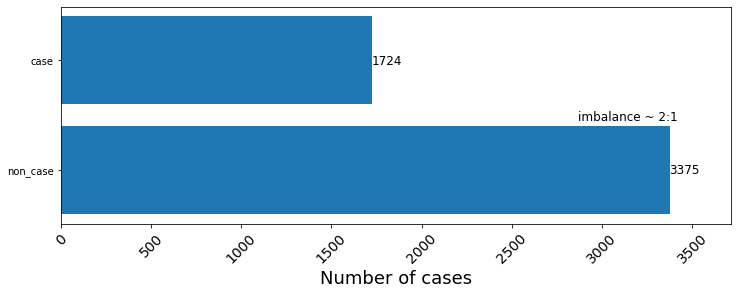

In [5]:
plot_imbalance(dataset, target_column='cases')

In [6]:
#dataset = dataset.query('month >= 5 & month <= 11')
dataset = dataset.query('month >= 5')
dataset.reset_index(drop=True, inplace=True)

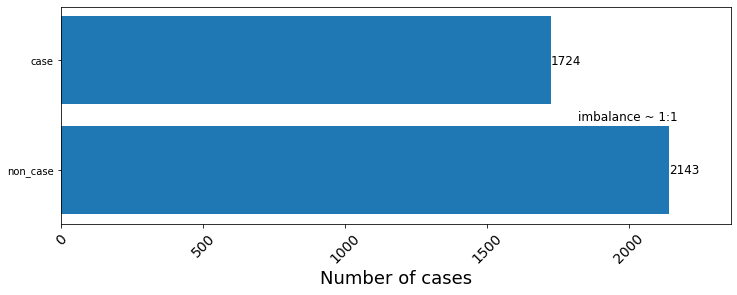

In [7]:
plot_imbalance(dataset, target_column='cases')

In [8]:
dataset.shape

(2464, 114)

In [9]:
dataset.cases.sum()

1724

In [10]:
dsc = dataframe_describe(dataset, target_column = 'cases')
dsc.head(15)

,year,non-case,case,total,0/1 ratio
0,2010,152,260,412,0.58%
1,2011,144,91,235,1.58%
2,2012,150,141,291,1.06%
3,2013,152,83,235,1.83%
4,2014,171,13,184,13.15%
5,2015,176,0,176,inf%
6,2016,176,0,176,inf%
7,2017,176,0,176,inf%
8,2018,125,293,418,0.43%
9,2019,135,221,356,0.61%


In [11]:
X = dataset.select_dtypes(exclude=['object']).drop(columns=['cases'])
y = dataset['cases']

In [12]:
n_folds = 10
k_fold = StratifiedKFold(n_splits = n_folds, shuffle = True, random_state = 0)
#k_fold = KFold(n_splits = n_folds, shuffle = True, random_state = 0)

In [13]:

features_to_remove = ['x', 'y', 'year', 'month', 'lc_prop1', 'lc_prop2', 'lc_prop3', 'lc_type1', 'lc_type2', 'lc_type3', 'lc_type4', 'lc_type5', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km', 'flow_accu_200m', 'distance_to_coast_min', 'distance_to_river_min', 'slope_mean_1km_min', 'aspect_mean_200m_min', 'elevation_mean_1km_min', 'hillshade_mean_1km_min', 'fs_area_1km_min', 'flow_accu_200m_min', 'distance_to_coast_max', 'distance_to_river_max', 'slope_mean_1km_max', 'aspect_mean_200m_max', 'elevation_mean_1km_max', 'hillshade_mean_1km_max', 'fs_area_1km_max', 'flow_accu_200m_max', 'distance_to_coast_std', 'distance_to_river_std', 'slope_mean_1km_std', 'aspect_mean_200m_std', 'elevation_mean_1km_std', 'hillshade_mean_1km_std', 'fs_area_1km_std', 'flow_accu_200m_std']
features_to_remove = features_to_remove + ['ndbi', 'ndbi_std', 'females_total', 'females_15t64']
#features_to_remove = ['x', 'y', 'year', 'month']
feature_names = X.select_dtypes(exclude=['object']).drop(columns = features_to_remove).columns
print(feature_names.to_list())

['ndvi', 'ndmi', 'ndwi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'lst_day_mean', 'lst_jan_day_mean', 'lst_feb_day_mean', 'lst_mar_day_mean', 'lst_apr_day_mean', 'lst_night_mean', 'lst_jan_night_mean', 'lst_feb_night_mean', 'lst_mar_night_mean', 'lst_apr_night_mean', 'lst_mean', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'monthly_lst_min', 'monthly_lst_max', 'rainfall_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_month', 'acc_rainfall_jan', 'mosq_pred_acc', 'mosq_pred_mean', 'bio1', 'bio2', 'bio3', 'bio4', 'bio5', 'bio6', 'bio7', 'bio8', 'bio9', 'bio10', 'bio11', 'bio12', 'bio13', 'bio14', 'bio15', 'bio16', 'bio17', 'bio18', 'bio19', 'males_lt15', 'males_15t64', 'males_gt65', 'males_total', 'females_lt15', 'females_gt65', 'mio_eur', 'l_total', 'unl_total', 'month_sin', 'month_cos']


In [14]:
print(f"Total Features Used: {len(feature_names)}")

Total Features Used: 64


In [15]:
fold_counter = 0
y_train_list = []
y_test_list = []
y_train_prob_list = []
y_test_prob_list = []

for train_idx, test_idx in k_fold.split(X, y):
    print(f'Fold: {fold_counter+1}/{n_folds}')

    data_train = dataset.iloc[train_idx]
    data_test = dataset.iloc[test_idx]

    data_train = convert_multiple_cases(data_train, target_col='cases')
    #data_train['cases'] = data_train['cases'].apply(lambda x: 1 if x > 0 else 0)
    data_test['cases'] = data_test['cases'].apply(lambda x: 1 if x > 0 else 0)

    data_train.reset_index(inplace = True, drop = True)
    data_test.reset_index(inplace = True, drop = True)

    sum_negatives = data_train['cases'].value_counts().get(0)
    sum_positives = data_train['cases'].value_counts().get(1)

    params = {
        "objective": "binary:logistic",
        "device": "gpu", 
        "eval_metric": "logloss",
        "learning_rate": 0.15,
        "min_split_loss": 0.5,
        "max_depth": 3, 
        "reg_alpha": 0.5,
        "reg_lambda": 0.5,
        "min_child_weight": 1.5,
        "scale_pos_weight": sum_negatives/sum_positives, 
    }


    X_train = data_train.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
    X_test = data_test.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])

    y_train = data_train['cases']
    y_test = data_test['cases']

    print(f"Training set 0/1 Ratio: {(data_train['cases'].value_counts().get(0) / data_train['cases'].value_counts().get(1)):.2f}")
    print(f"Test set 0/1 Ratio: {(data_test['cases'].value_counts().get(0) / data_test['cases'].value_counts().get(1)):.2f}")
    print(f"Weight: {(sum_negatives/sum_positives):.2f}")
    
    scaler = MinMaxScaler(feature_range = (-1, 1))
    #scaler = RobustScaler()
    scaler.fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    X_test_scaled = scaler.transform(X_test)
            
    imputer = KNNImputer()
    imputer.fit(X_train)
    X_train_imputed = imputer.transform(X_train_scaled)
    X_test_imputed = imputer.transform(X_test_scaled)

    model = xgb.XGBClassifier(**params)   
    trained_model = model.fit(X_train_imputed, y_train)

    y_train_prob = trained_model.predict_proba(X_train_imputed)
    y_test_prob = trained_model.predict_proba(X_test_imputed)

    y_train_list.append(y_train)
    y_test_list.append(y_test)
    y_train_prob_list.append(y_train_prob)
    y_test_prob_list.append(y_test_prob)
    fold_counter += 1

Fold: 1/10
Training set 0/1 Ratio: 1.25
Test set 0/1 Ratio: 6.72
Weight: 1.25
Fold: 2/10
Training set 0/1 Ratio: 1.26
Test set 0/1 Ratio: 6.72
Weight: 1.26
Fold: 3/10
Training set 0/1 Ratio: 1.30
Test set 0/1 Ratio: 6.72
Weight: 1.30
Fold: 4/10
Training set 0/1 Ratio: 1.27
Test set 0/1 Ratio: 6.48
Weight: 1.27
Fold: 5/10
Training set 0/1 Ratio: 1.22
Test set 0/1 Ratio: 6.69
Weight: 1.22
Fold: 6/10
Training set 0/1 Ratio: 1.22
Test set 0/1 Ratio: 6.69
Weight: 1.22
Fold: 7/10
Training set 0/1 Ratio: 1.26
Test set 0/1 Ratio: 6.69
Weight: 1.26
Fold: 8/10
Training set 0/1 Ratio: 1.23
Test set 0/1 Ratio: 6.69
Weight: 1.23
Fold: 9/10
Training set 0/1 Ratio: 1.23
Test set 0/1 Ratio: 6.69
Weight: 1.23
Fold: 10/10
Training set 0/1 Ratio: 1.21
Test set 0/1 Ratio: 6.69
Weight: 1.21


In [16]:
y_train_true = np.concatenate(y_train_list, axis=0)
y_test_true = np.concatenate(y_test_list, axis=0)

y_train_proba = np.concatenate(y_train_prob_list, axis = 0)
y_test_proba = np.concatenate(y_test_prob_list, axis = 0)

In [17]:
train_loss = log_loss(y_train_true, y_train_proba[:, 1])
print(f"Train Logloss: {train_loss:.4f}")

test_loss = log_loss(y_test_true, y_test_proba[:, 1])
print(f"Test Loss: {test_loss:.4f}")

Train Logloss: 0.0815
Test Loss: 0.1906


In [18]:
classification_thresholds = optimal_threashold_fbeta_scalar(y_train_proba[:,1], y_train_true, beta = 2, round_factor = 2)
print(classification_thresholds)

0.4


In [19]:
thr = classification_thresholds

In [20]:
y_train_pred = np.where(y_train_proba[:,1] > thr, 1, 0)
y_test_pred = np.where(y_test_proba[:,1] > thr, 1, 0)

In [21]:
print(classification_report(y_test_true, y_test_pred, output_dict=False))

              precision    recall  f1-score   support

           0       0.97      0.93      0.95      2143
           1       0.63      0.82      0.71       321

    accuracy                           0.91      2464
   macro avg       0.80      0.87      0.83      2464
weighted avg       0.93      0.91      0.92      2464



In [22]:
'''
MCM = [[TN, FP],
       [FN, TP]]
'''


cm = confusion_matrix(y_test_true, y_test_pred)

print(cm)

[[1987  156]
 [  59  262]]


In [23]:
data_train_shap = dataset.copy()
#data_train_shap = convert_multiple_cases(data_train_shap, target_col='cases')
data_train_shap['cases'] = data_train_shap['cases'].apply(lambda x: 1 if x > 0 else 0)

X_train = data_train_shap.select_dtypes(exclude=['object']).drop(columns = features_to_remove + ['cases'])
y_train = data_train_shap['cases']

sum_negatives = data_train_shap['cases'].value_counts().get(0)
sum_positives = data_train_shap['cases'].value_counts().get(1)

scaler = MinMaxScaler(feature_range = (-1, 1))
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
            
imputer = KNNImputer()
imputer.fit(X_train)
X_train_imputed = imputer.transform(X_train_scaled)
X_train_imputed = pd.DataFrame(X_train_imputed, columns=X_train.columns)


In [24]:
# Tree explainer

# curently not working with multioutput models

params["scale_pos_weight"] = sum_negatives/sum_positives

model = xgb.XGBClassifier(**params)   
trained_model = model.fit(X_train_imputed, y_train)

tree_explainer = shap.TreeExplainer(model)
#tree_shap_values = tree_explainer.shap_values(X_train_imputed)
tree_shap_values = tree_explainer(X_train_imputed)

In [25]:
# shap_values_path = r'E:\Drive\NOA\MBD-Prediction\JRC Interpretability\Greece\data\ValuesShap\GR_OP_2010-2023_Tree_Shapely_Values.npz'

# np.savez(shap_values_path, *tree_shap_values)

# # shap_values = []
# # loaded_shap_values = np.load(shap_values_path)

# # for key in loaded_shap_values.keys():
# #     shap_values.append(loaded_shap_values[key])

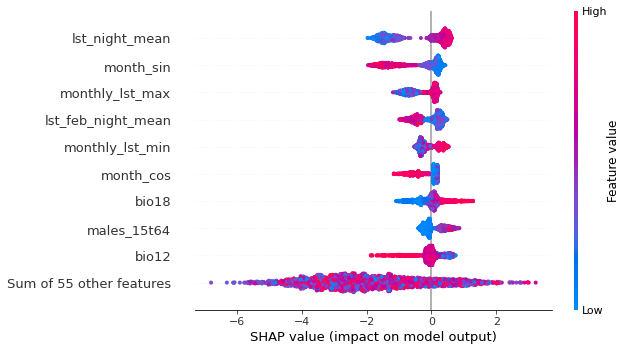

In [26]:
shap.plots.beeswarm(shap_values = tree_shap_values, max_display=10)

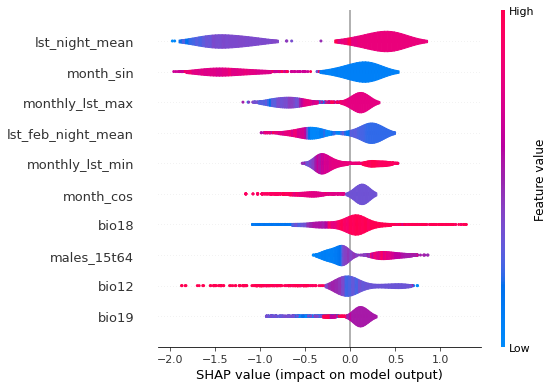

In [27]:
shap.summary_plot(tree_shap_values, feature_names = X_train.columns, features = X_train_imputed, plot_type='violin', max_display=10)

In [28]:
shap_lim = (-2, 1.5)

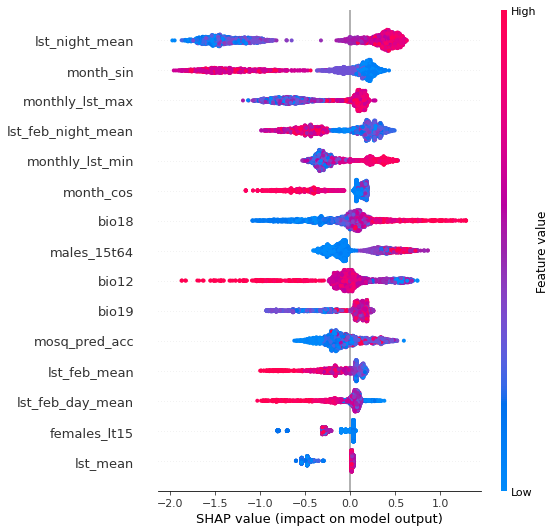

In [29]:
shap.summary_plot(tree_shap_values.values, feature_names = X_train.columns, features = tree_shap_values.data, max_display=15)

In [30]:
location_columns = data_train_shap.iloc[:, :5]
wnv_columns = data_train_shap['cases']

In [31]:
tree_shap_values_df = pd.DataFrame(tree_shap_values.values, columns=X_train.columns)
tree_shap_values_df = pd.concat([location_columns, tree_shap_values_df, wnv_columns], axis=1)

In [32]:
X_train

,ndvi,ndmi,ndwi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_gt65,mio_eur,l_total,unl_total,month_sin,month_cos
0,0.408398,0.144143,-0.235554,0.412976,0.140501,-0.242655,-0.140501,0.044047,0.046857,0.041740,22.445667,6.180824,6.775942,16.031804,22.445667,7.345457,2.721929,1.588987,3.674767,7.345457,14.895562,4.451377,4.182464,9.853286,14.895562,4.901481,27.258519,2.472640,8.438265,56.295983,74.179192,558.574506,744.314815,24.810494,14.333333,19.666667,40.972222,832.120329,37.0,-11.0,48.0,5.500000,23.500000,24.000000,4.166667,1455.0,296.0,45.0,62.908014,664.0,194.0,259.0,576.0,11723.0,44888.0,13557.0,70168.0,11361.0,16024.0,2098.63,4287.0,4163.0,5.000000e-01,-0.866025
1,0.417461,0.158374,-0.240587,0.404465,0.156728,-0.228864,-0.156728,0.043854,0.042760,0.033155,22.021724,7.924345,8.919715,16.838180,22.021724,8.176359,1.718196,2.592662,4.207480,8.176359,15.099042,4.821270,5.756189,10.522830,15.099042,6.827969,27.816719,2.203142,14.748729,43.918049,66.094267,462.422352,670.359375,22.345312,16.083333,21.166667,45.035461,888.265248,42.0,-5.0,47.0,7.166667,9.500000,27.333333,5.666667,1324.0,291.0,35.0,66.632744,587.0,184.0,280.0,547.0,87281.0,374669.0,80103.0,542053.0,83839.0,104992.0,21520.33,13373.0,15210.0,5.000000e-01,-0.866025
2,0.392183,0.130465,-0.244458,0.412952,0.161777,-0.227281,-0.161777,0.037472,0.039575,0.034869,22.303014,7.171515,8.296955,17.445933,22.303014,7.777080,0.395722,2.653680,3.611627,7.777080,15.040047,3.783619,5.475318,10.528780,15.040047,6.112391,27.085435,2.711588,17.818245,55.373941,81.347629,421.128773,742.434783,24.747826,16.041667,22.916667,44.070513,929.187899,44.0,-8.0,52.0,6.666667,9.333333,27.666667,5.333333,1381.0,286.0,41.0,63.457161,604.0,204.0,300.0,550.0,5916.0,24162.0,9803.0,39881.0,5598.0,11860.0,1169.86,1295.0,1347.0,5.000000e-01,-0.866025
3,0.381620,0.110083,-0.250977,0.377433,0.113646,-0.243337,-0.113646,0.046019,0.057493,0.058804,21.915439,6.421928,7.326073,16.352680,21.915439,7.384265,0.948226,1.228491,3.502273,7.384265,14.649852,3.685077,4.277282,9.927476,14.649852,5.501364,26.012500,3.065290,14.986248,74.327196,91.958696,548.595249,783.284091,26.109470,14.708333,19.916667,43.297101,849.186331,38.0,-8.0,46.0,6.000000,24.500000,25.166667,4.666667,1512.0,287.0,44.0,60.410595,683.0,204.0,288.0,579.0,11214.0,44608.0,14535.0,70357.0,11089.0,17464.0,2022.78,4098.0,3272.0,5.000000e-01,-0.866025
4,0.407794,0.137249,-0.248980,0.391699,0.159604,-0.198897,-0.159604,0.043321,0.042688,0.046069,20.919348,8.251190,8.896448,17.043577,20.919348,8.339467,3.891950,2.624206,4.600036,8.339467,14.629407,6.071570,5.760327,10.821806,14.629407,6.584222,25.696667,2.168862,5.630293,42.323696,65.065875,531.063941,1015.688889,33.856296,15.500000,19.500000,43.333333,837.745893,40.0,-5.0,45.0,7.333333,25.166667,26.000000,5.666667,1275.0,275.0,51.0,66.546526,571.0,176.0,199.0,521.0,10377.0,39695.0,11841.0,61913.0,10120.0,14312.0,1815.79,2073.0,2335.0,5.000000e-01,-0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.571742,12.777786,18.078129,18.078129,NaN,8.141290,6.215929,9.757226,9.757226,NaN,10.856516,9.496857,13.917677,13.917677,10.983600,26.301771,NaN,0.000000,0.000000,0.000000,484.3

In [33]:
tree_shap_values_df

,NUTS3_ID,year,month,x,y,ndvi,ndmi,ndwi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,lst_day_mean,lst_jan_day_mean,lst_feb_day_mean,lst_mar_day_mean,lst_apr_day_mean,lst_night_mean,lst_jan_night_mean,lst_feb_night_mean,lst_mar_night_mean,lst_apr_night_mean,lst_mean,lst_jan_mean,lst_feb_mean,lst_mar_mean,lst_apr_mean,monthly_lst_min,monthly_lst_max,rainfall_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_month,acc_rainfall_jan,mosq_pred_acc,mosq_pred_mean,bio1,bio2,bio3,bio4,bio5,bio6,bio7,bio8,bio9,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19,males_lt15,males_15t64,males_gt65,males_total,females_lt15,females_gt65,mio_eur,l_total,unl_total,month_sin,month_cos,cases
0,EL521,2010,5,22.217953,40.552111,-0.006357,-0.093388,-0.053406,-0.038183,0.017884,-0.071844,0.044316,-0.127693,0.114694,0.051350,-0.282849,0.142685,-0.016908,-0.094229,-0.016460,-1.667120,-0.072716,0.233287,-0.011063,-0.053217,-0.478252,0.035567,0.169491,-0.007002,-0.034576,-0.469692,-0.665810,-0.049051,0.039543,-0.037918,0.032849,-0.071269,-0.055794,-0.071760,0.005830,0.029793,0.066605,-0.086469,0.001305,0.007390,0.044027,0.013121,-0.031299,-0.004426,0.029643,0.001486,0.052883,0.322118,-0.041351,-0.017471,-0.055290,0.087447,0.102684,0.059001,-0.035008,-0.192842,-0.030198,0.038143,-0.001887,0.094247,0.002424,-0.045353,-1.545971,0.068826,0
1,EL522,2010,5,23.139033,40.693632,-0.006357,-0.050875,-0.053705,0.007116,0.022679,-0.136070,0.033037,-0.133334,0.094943,0.004854,-0.339432,-0.072076,-0.022922,0.068681,-0.016460,-1.742030,-0.049856,0.138725,-0.011063,-0.037009,-0.478252,0.035567,0.155627,-0.007002,-0.039514,-0.469692,-0.740020,-0.055088,0.017672,-0.056691,-0.018420,-0.194191,-0.136196,-0.071081,0.039671,0.036477,0.077364,-0.081781,0.001305,-0.000348,0.040147,0.010343,0.097320,0.022023,0.031562,0.009982,0.052883,0.226263,-0.044773,0.038705,-0.052172,0.114152,0.122455,0.145492,0.504207,-0.261726,0.115515,-0.274951,-0.001887,0.131575,0.009572,-0.023906,-1.559059,0.068958,0
2,EL523,2010,5,22.762317,41.016275,-0.006357,-0.104272,-0.122833,-0.024199,0.019345,-0.072506,0.072065,-0.145154,0.107501,-0.007452,-0.293649,0.146429,-0.012715,0.076610,-0.001812,-1.791865,0.083721,0.171208,-0.011063,-0.044121,-0.432882,0.035242,0.170622,-0.115363,-0.039514,-0.491870,-0.650816,-0.045315,0.031963,-0.080117,0.006328,-0.277707,-0.063301,-0.049443,0.068075,-0.141146,0.290608,-0.012829,-0.006053,0.007390,0.022045,0.004904,0.047861,0.016846,0.029643,0.117115,0.072680,0.371698,-0.049924,0.027245,-0.041901,0.299789,0.104705,-0.199872,-0.274482,0.279746,-0.046182,-0.100628,-0.001887,-0.185921,0.002424,-0.057504,-1.336588,0.083601,0
3,EL524,2010,5,22.109782,40.888821,-0.006357,-0.093388,-0.054340,-0.038183,-0.015674,-0.072222,-0.043774,-0.153422,-0.103333,-0.067372,-0.282849,0.091141,0.059216,-0.092202,-0.016460,-1.799832,-0.046298,0.241895,-0.011063,-0.044121,-0.478252,0.041547,0.169491,-0.007002,-0.034576,-0.469692,-0.661616,-0.049051,0.039021,-0.111765,0.032849,-0.075695,-0.124344,-0.071760,0.001160,-0.030804,0.070536,-0.109056,0.001305,0.007390,0.056777,0.013121,-0.031299,-0.026970,0.026058,-0.010716,0.035667,0.295002,-0.293226,-0.017471,-0.045296,0.323031,0.094418,-0.159676,-0.035008,-0.201654,-0.017786,0.038143,-0.001887,0.094247,0.002424,-0.032297,-1.617897,0.068826,0
4,EL525,2010,5,22.442423,40.269959,-0.006357,-0.104272,-0.053406,-0.005615,0.017884,-0.078092,0.082888,-0.127693,0.112923,0.035382,-0.292459,-0.071422,-0.007046,0.068681,-0.016460,-1.671332,-0.125629,0.164429,-0.011063,-0.053217,-0.478252,0.035567,0.170622,-0.007002,-0.039514,-0.500550,-0.727152,-0.058824,0.057385,-0.040608,0.008101,-0.071269,-0.112842,-0.001005,0.010607,-0.023722,0.097780,-0.085414,0.001305,-0.000348,-0.011418,0.013121,-0.031299,-0.026970,0.029643,0.018856,0.008427,0.292758,-0.041351,0.027245,-0.012274,0.136143,0.108060,-0.151171,-0.139413,-0.192842,-0.058593,0.038143,-0.001887,0.092079,0.002424,-0.043018,-1.706983,0.068826,0
...,...,...,...,...,...,...,...

In [34]:
sorted_mean_abs_values_idx = tree_shap_values_df.iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
sorted_mean_abs_values_idx

Index(['lst_night_mean', 'month_sin', 'monthly_lst_max', 'lst_feb_night_mean',
       'monthly_lst_min', 'month_cos', 'bio18', 'males_15t64', 'bio12',
       'bio19', 'mosq_pred_acc', 'lst_feb_mean', 'lst_feb_day_mean',
       'females_lt15', 'lst_mean', 'bio3', 'unl_total', 'lst_day_mean',
       'males_gt65', 'ndwi', 'bio15', 'bio14', 'mio_eur', 'bio4',
       'acc_rainfall_jan', 'bio2', 'bio17', 'males_lt15', 'ndvi_std', 'bio11',
       'lst_jan_night_mean', 'lst_jan_mean', 'lst_jan_day_mean', 'bio13',
       'males_total', 'lst_mar_day_mean', 'rainfall_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'ndmi_std', 'ndmi',
       'ndvi_mean', 'acc_rainfall_month', 'ndbi_mean', 'ndwi_std',
       'lst_apr_mean', 'mosq_pred_mean', 'bio1', 'bio9', 'lst_mar_mean',
       'ndwi_mean', 'lst_apr_night_mean', 'bio8', 'bio16', 'ndmi_mean',
       'lst_mar_night_mean', 'bio7', 'bio10', 'ndvi', 'bio6',
       'lst_apr_day_mean', 'l_total', 'females_gt65', 'bio5'],
      dtype='object')

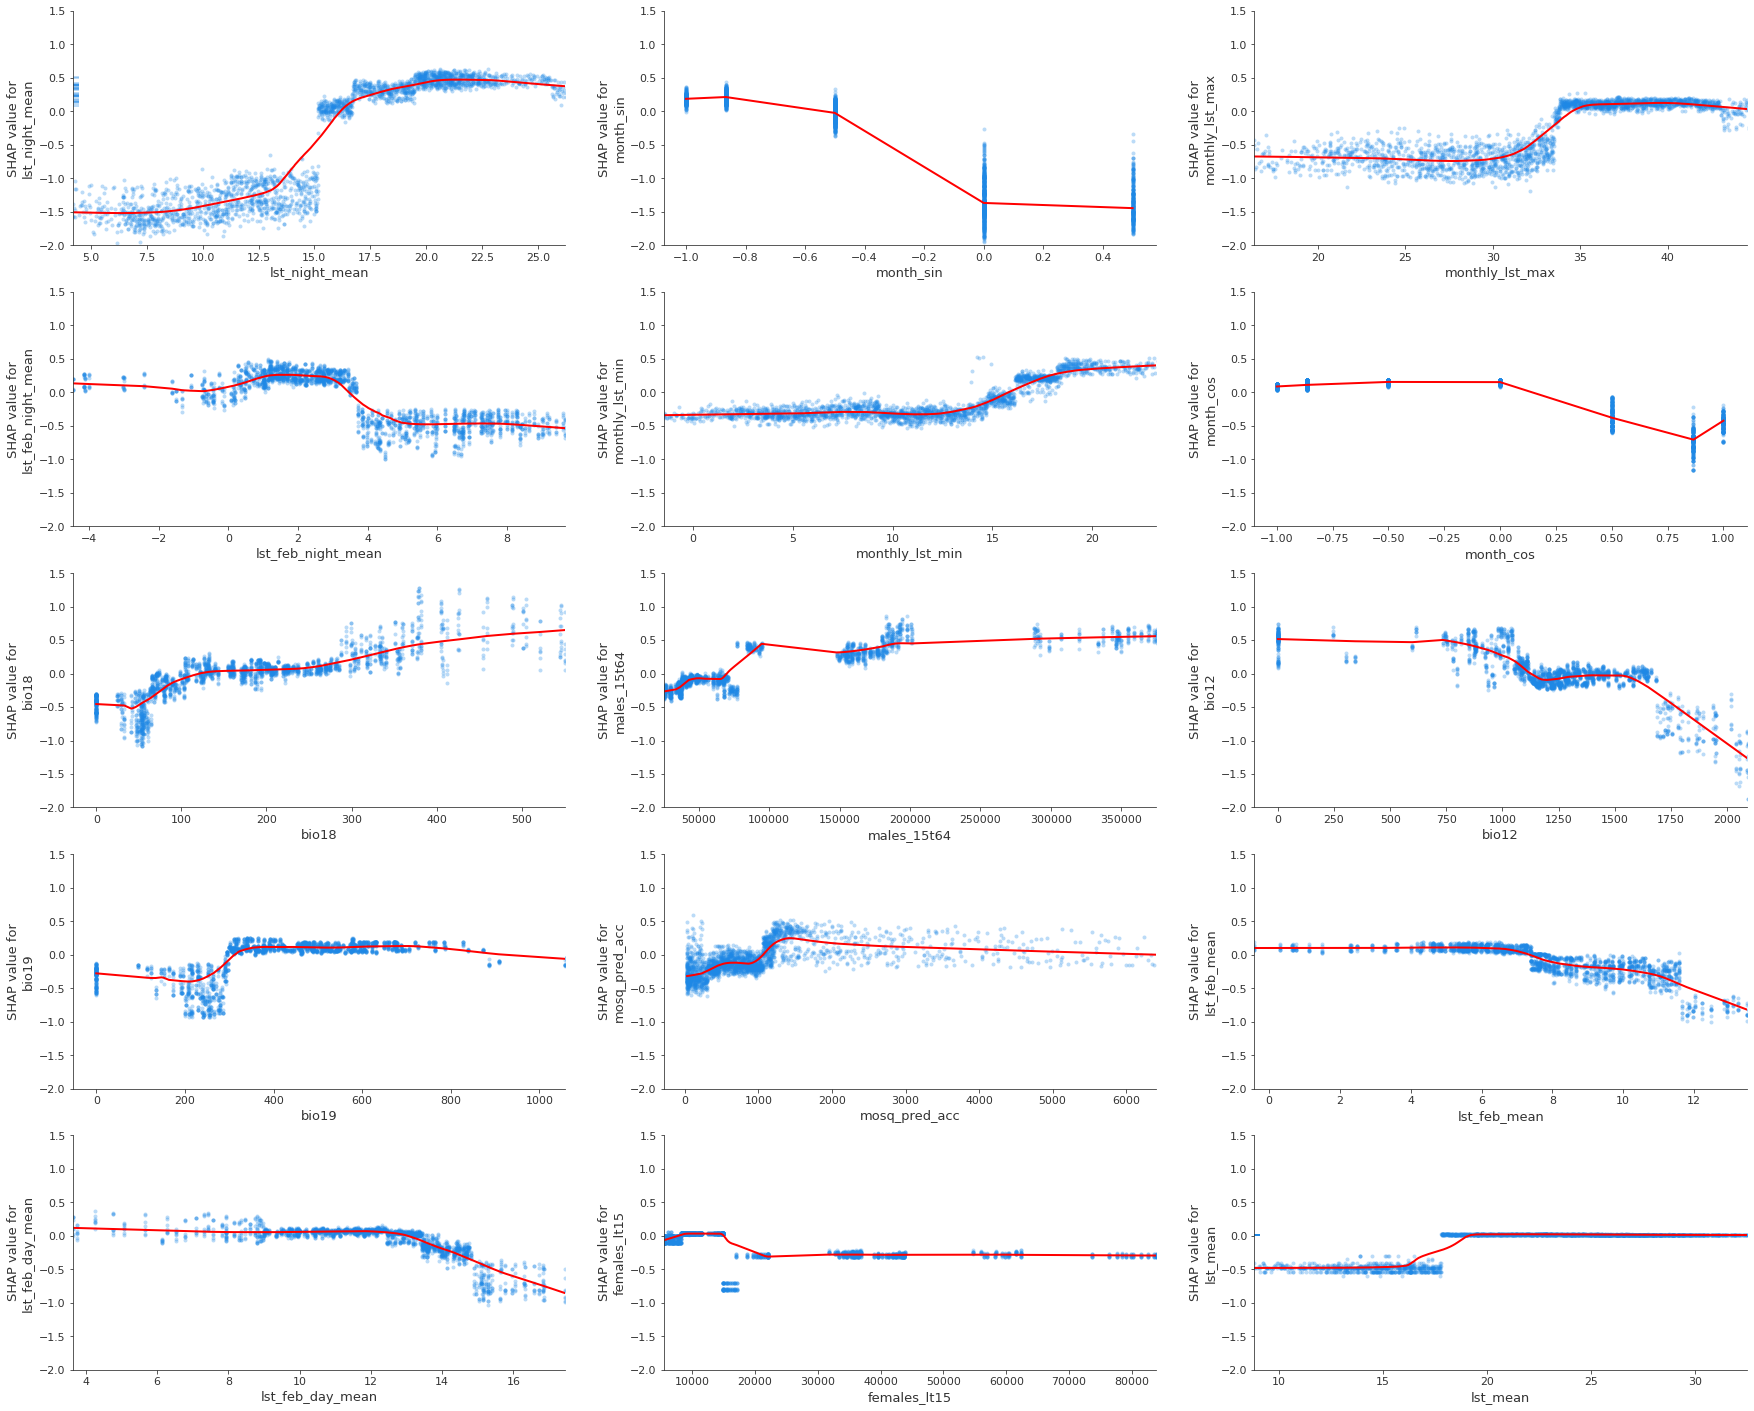

In [35]:
num_plots = 15

fig, axes = plt.subplots(5, 3, figsize=(30, 25))  # Adjust figsize as needed
i = 0

for ft in sorted_mean_abs_values_idx[:num_plots]:
    row = i // 3
    col = i % 3

    ax = axes[row, col]
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2, frac=.3)
    
    ax.plot(*list(zip(*lowess)), color="red", lw=2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind=feature, shap_values=shap_values, features=X_train, 
                         feature_names=feature_names, interaction_index=None, 
                         xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax=ax, show = False)
    
    i = i+1

plt.show()

    

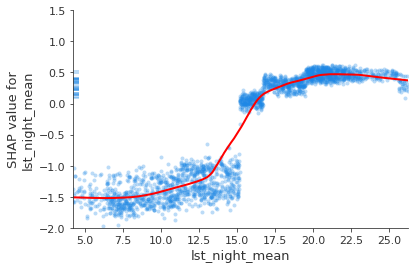

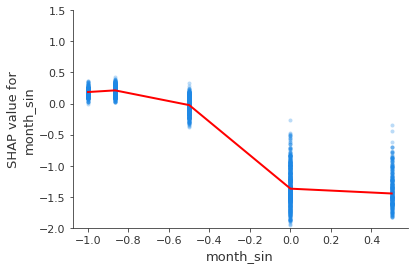

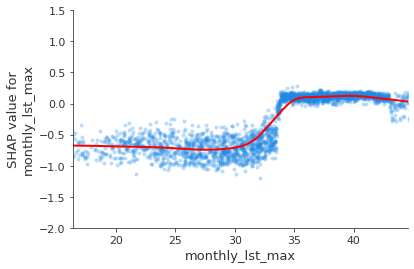

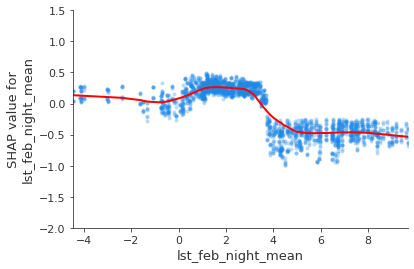

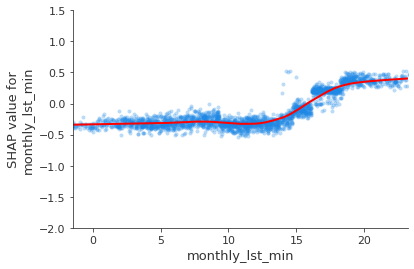

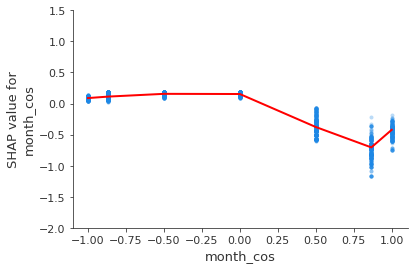

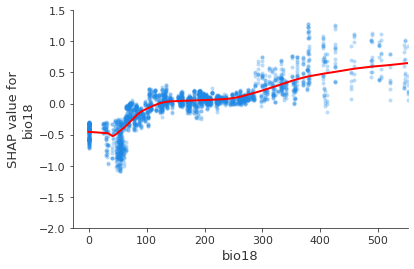

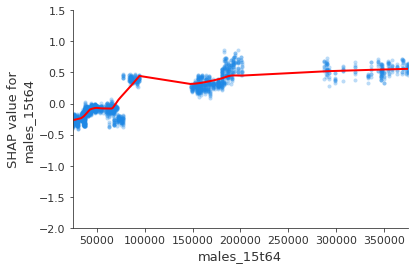

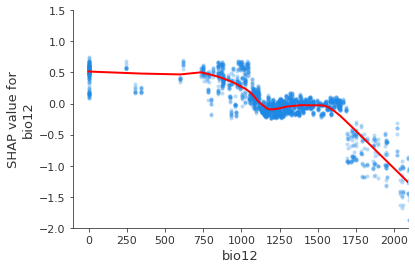

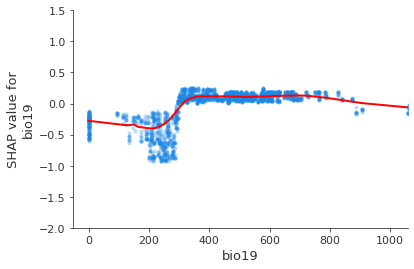

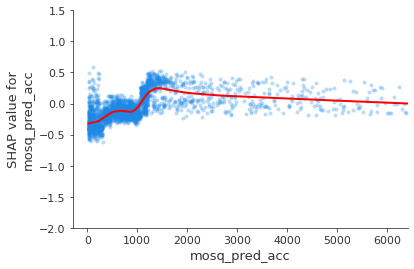

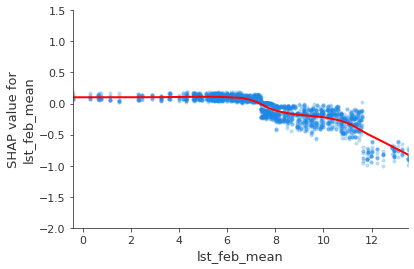

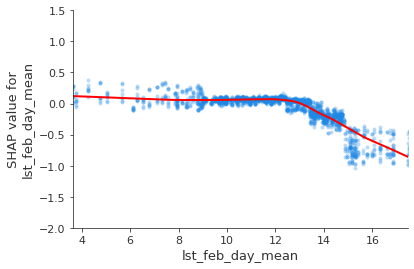

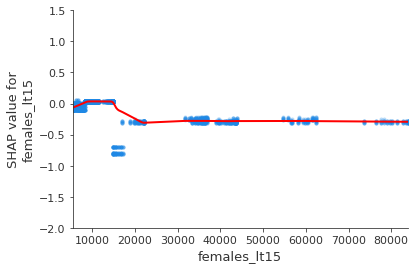

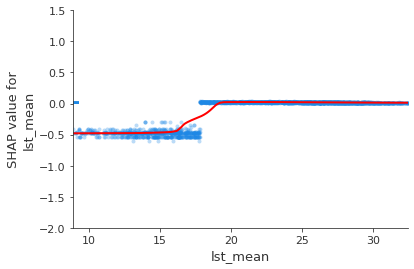

In [36]:
for ft in sorted_mean_abs_values_idx[:15]:
    feature = ft
    shap_values = tree_shap_values.values
    data = X_train
    feature_names = X_train.columns

    idx = np.where(X_train.columns==feature)[0][0]
    x = X_train.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(shap_lim)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = X_train, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

In [37]:
region_attica = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30'))
region_macedonia = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52'))
region_thrace = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL51'))
region_thessaly = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL61'))

shap_values_df_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].to_numpy()
shap_values_df_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].to_numpy()
shap_values_df_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].to_numpy()
shap_values_df_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].to_numpy()

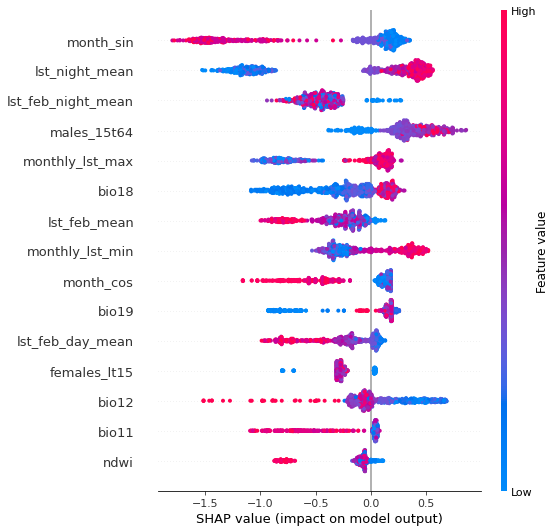

In [38]:
shap.summary_plot(shap_values_df_attica, feature_names = X_train.columns, features = X_train[region_attica], max_display=15)

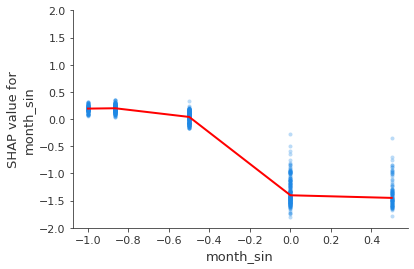

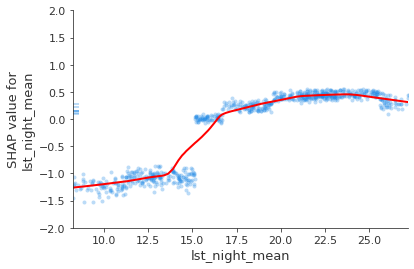

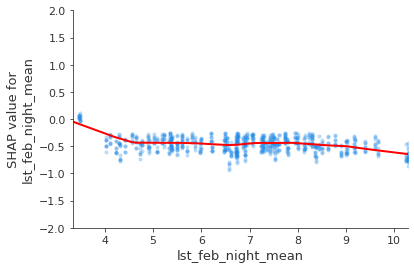

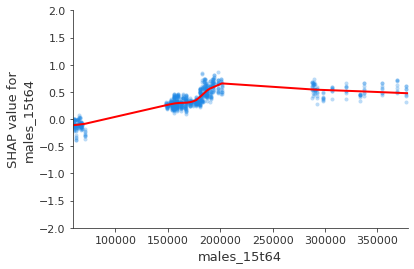

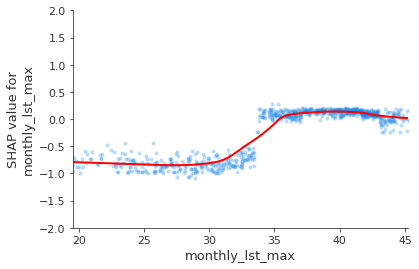

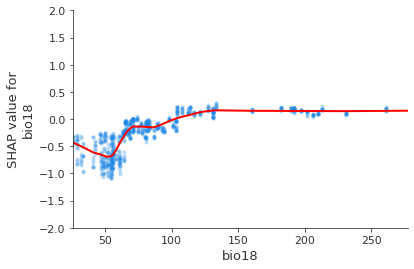

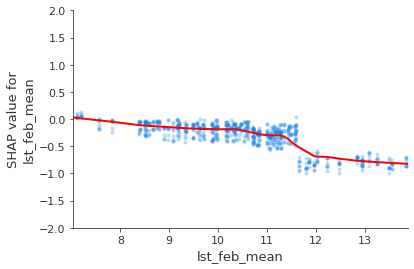

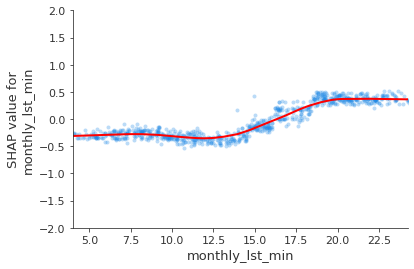

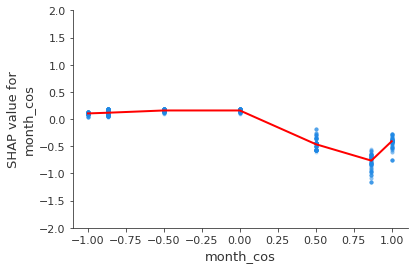

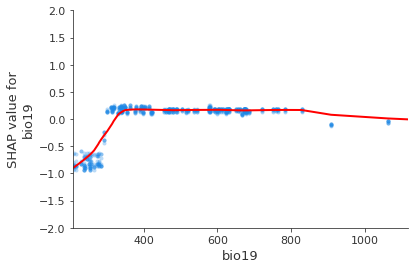

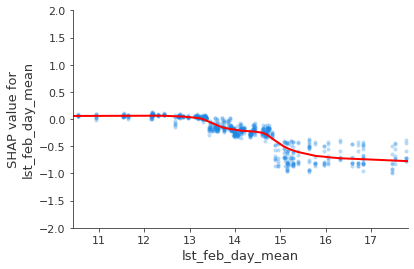

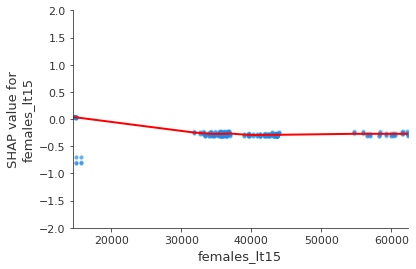

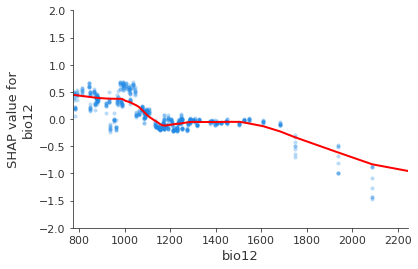

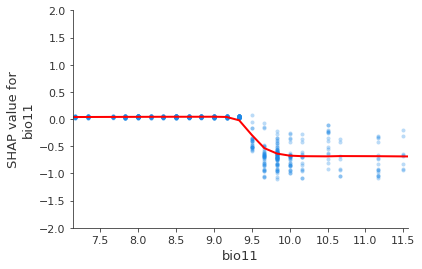

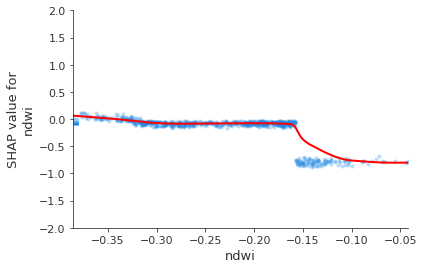

In [39]:
sorted_mean_abs_values_idx_attica = tree_shap_values_df[region_attica].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_attica[:15]:
    feature = ft
    shap_values = shap_values_df_attica
    data = X_train[region_attica]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

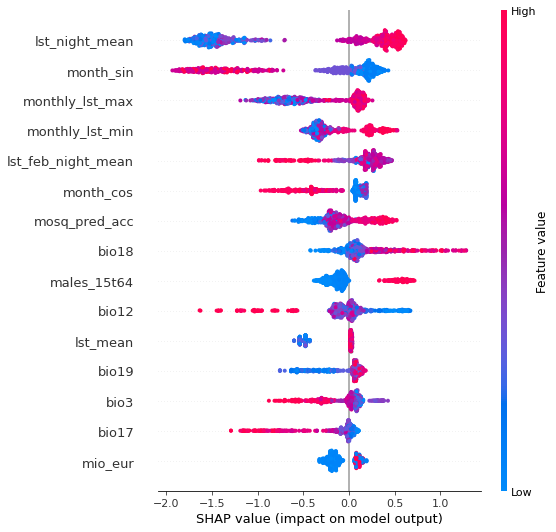

In [40]:
shap.summary_plot(shap_values_df_macedonia, feature_names = X_train.columns, features = X_train[region_macedonia], max_display=15)

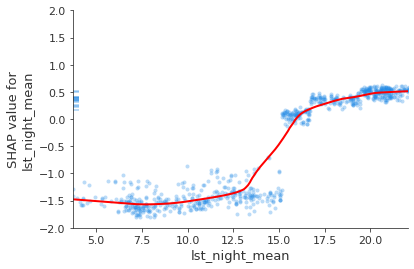

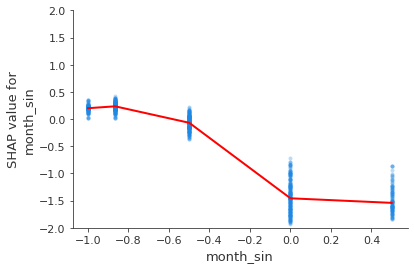

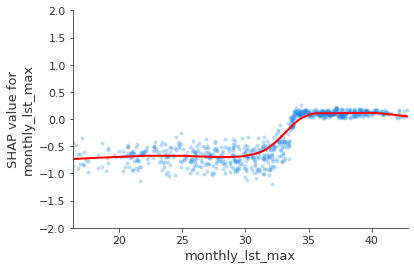

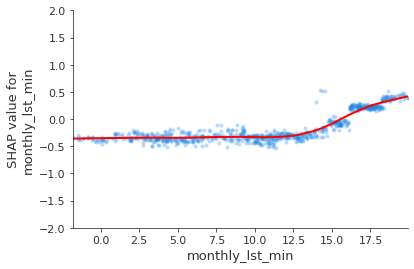

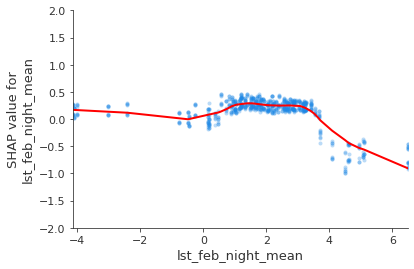

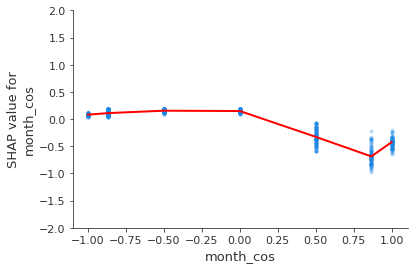

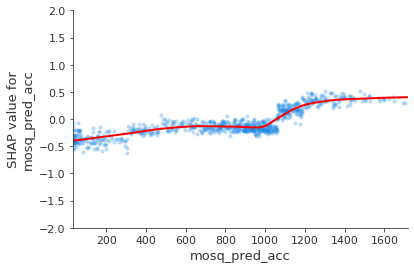

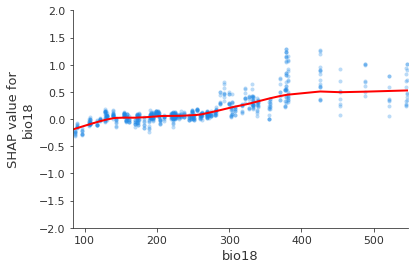

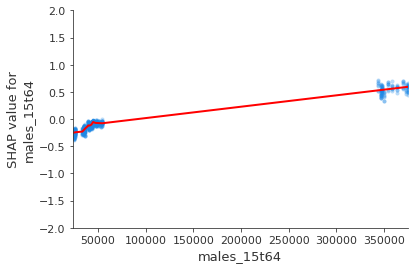

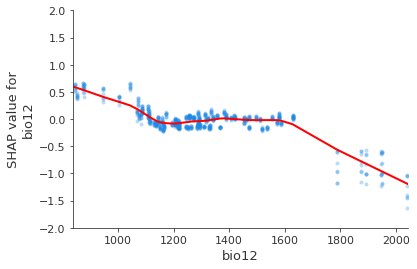

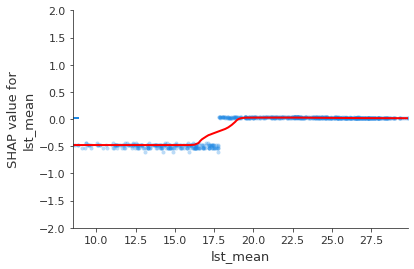

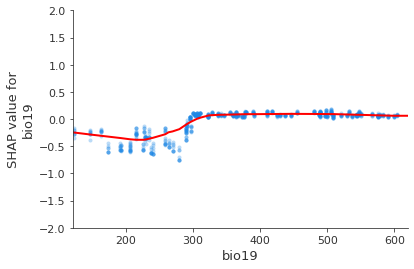

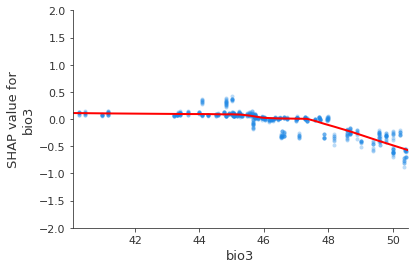

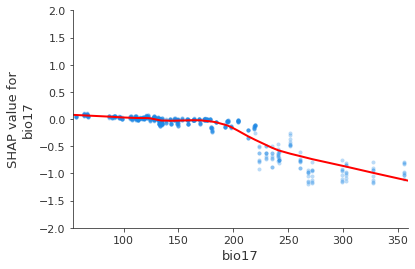

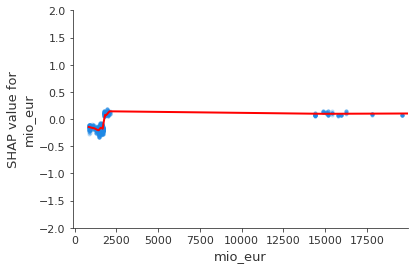

In [41]:
sorted_mean_abs_values_idx_macedonia = tree_shap_values_df[region_macedonia].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_macedonia[:15]:
    feature = ft
    shap_values = shap_values_df_macedonia
    data = X_train[region_macedonia]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

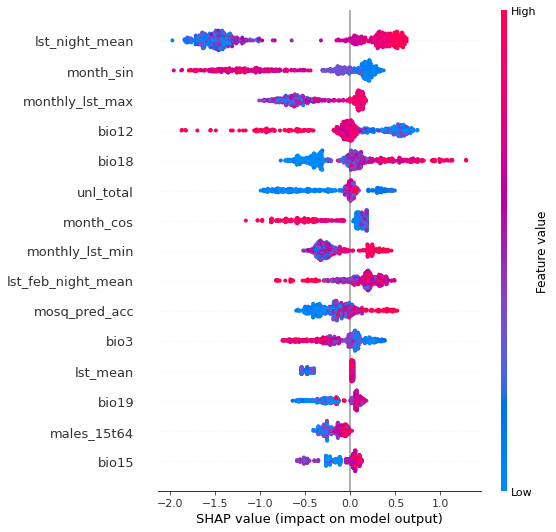

In [42]:
shap.summary_plot(shap_values_df_thrace, feature_names = X_train.columns, features = X_train[region_thrace], max_display=15)

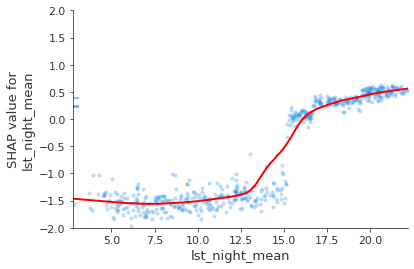

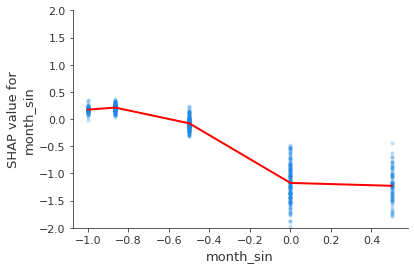

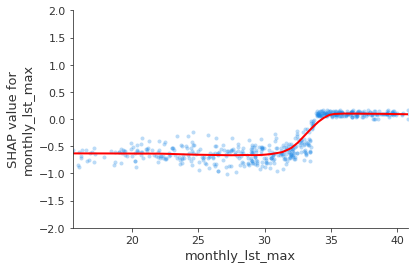

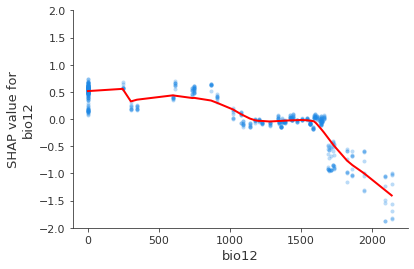

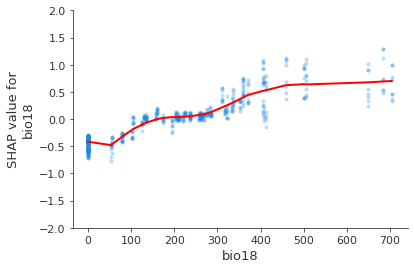

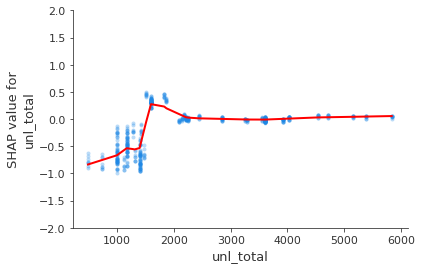

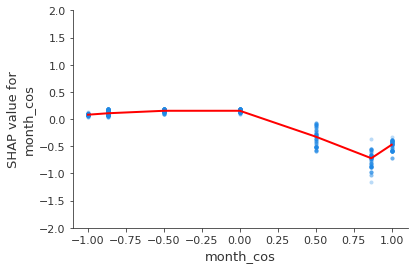

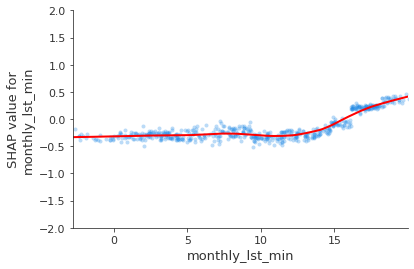

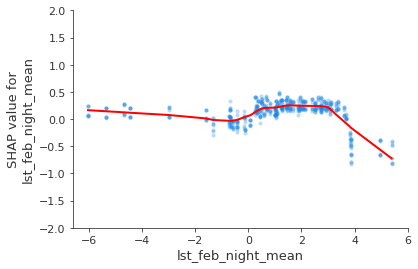

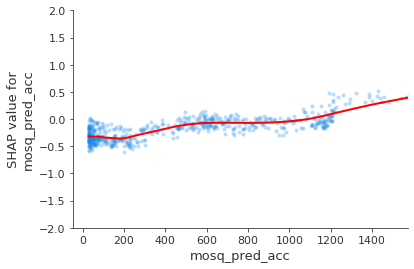

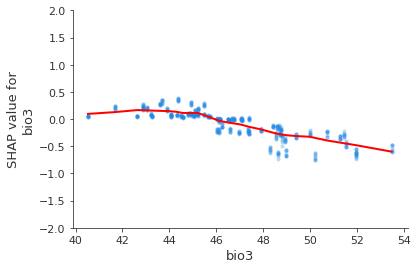

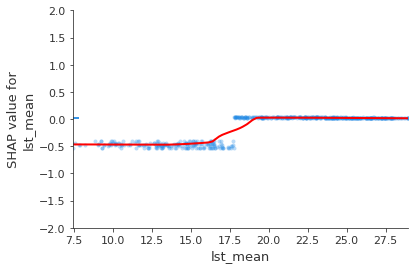

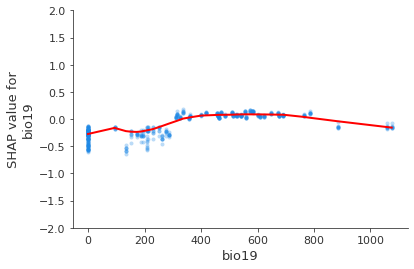

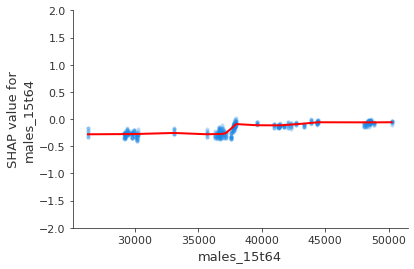

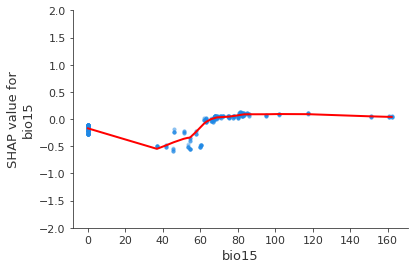

In [43]:
sorted_mean_abs_values_idx_thrace = tree_shap_values_df[region_thrace].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_thrace[:15]:
    feature = ft
    shap_values = shap_values_df_thrace
    data = X_train[region_thrace]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

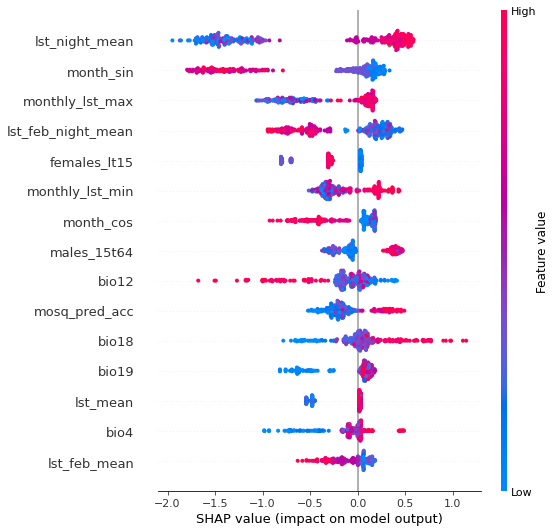

In [44]:
shap.summary_plot(shap_values_df_thessaly, feature_names = X_train.columns, features = X_train[region_thessaly], max_display=15)

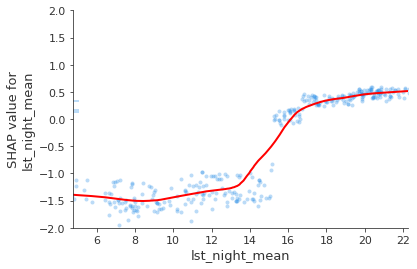

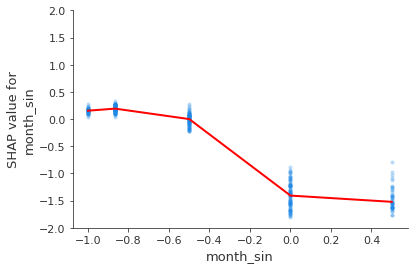

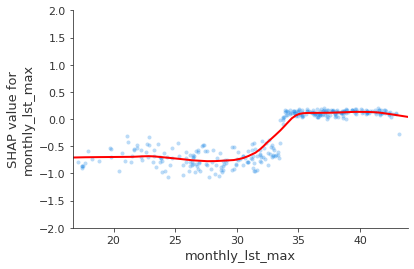

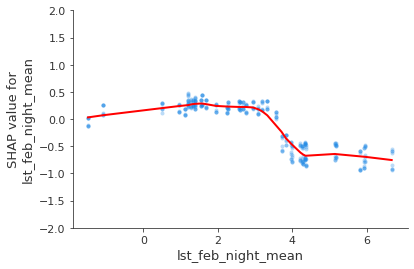

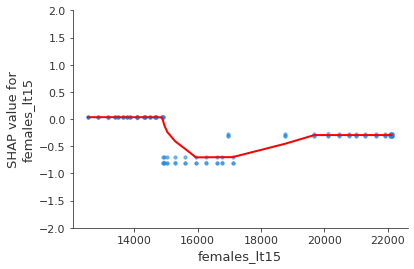

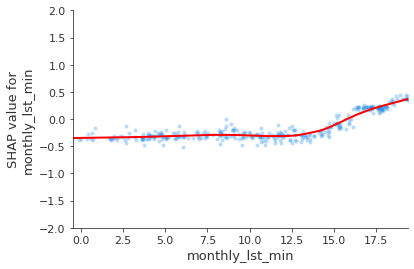

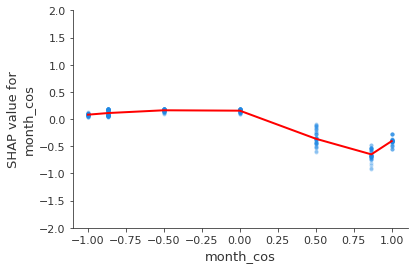

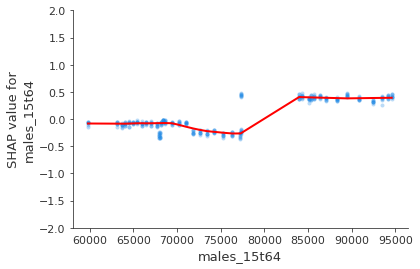

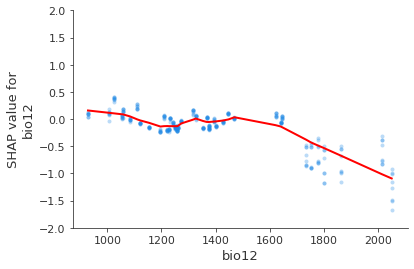

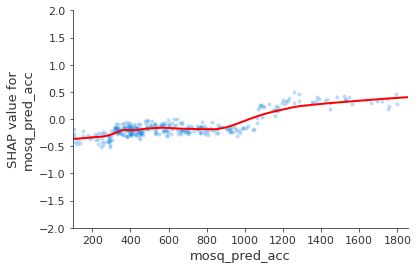

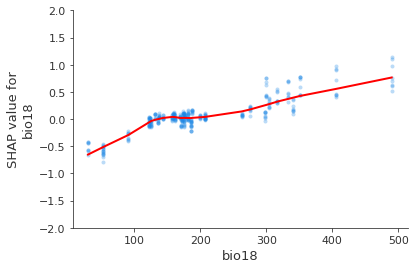

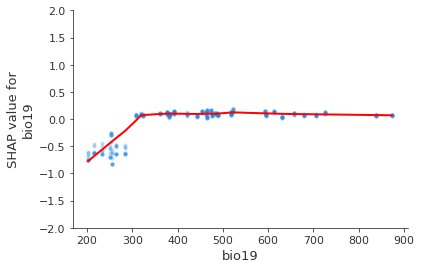

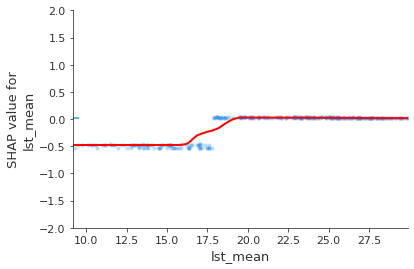

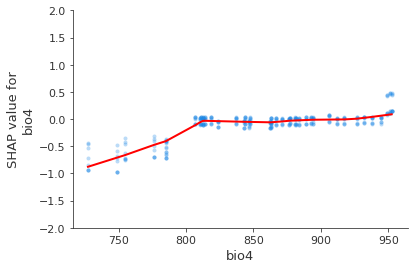

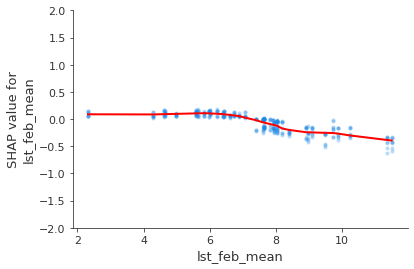

In [45]:
sorted_mean_abs_values_idx_thessaly = tree_shap_values_df[region_thessaly].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_thessaly[:15]:
    feature = ft
    shap_values = shap_values_df_thessaly
    data = X_train[region_thessaly]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

In [46]:
region_attica_high = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30')) & (tree_shap_values_df['year'].isin([2018]))
region_attica_low = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL30')) & (tree_shap_values_df['year'].isin([2010,2014,2015,2016,2017,2020,2021,2022,2023]))
region_macedonia_high = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52')) & (tree_shap_values_df['year'].isin([2010,2018,2022]))
region_macedonia_low = (tree_shap_values_df['NUTS3_ID'].str.startswith('EL52')) & (tree_shap_values_df['year'].isin([2014,2015,2016, 2017]))


shap_values_df_attica_high = tree_shap_values_df[region_attica_high].iloc[:, 5:-1].to_numpy()
shap_values_df_attica_low = tree_shap_values_df[region_attica_low].iloc[:, 5:-1].to_numpy()
shap_values_df_macedonia_high = tree_shap_values_df[region_macedonia_high].iloc[:, 5:-1].to_numpy()
shap_values_df_macedonia_low = tree_shap_values_df[region_macedonia_low].iloc[:, 5:-1].to_numpy()


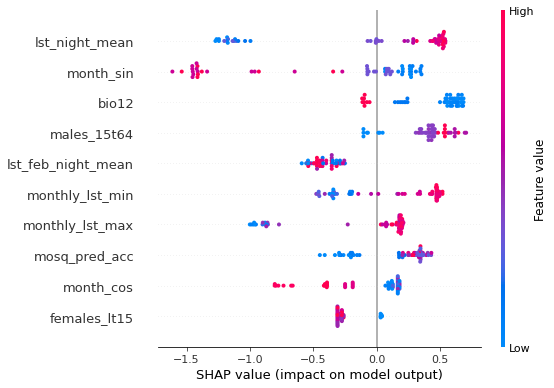

In [47]:
shap.summary_plot(shap_values_df_attica_high, feature_names = X_train.columns, features = X_train[region_attica_high], max_display=10)

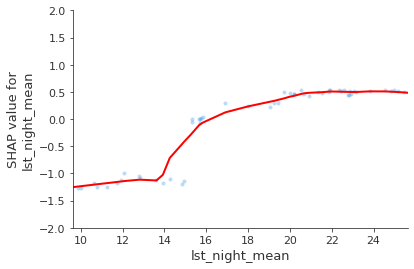

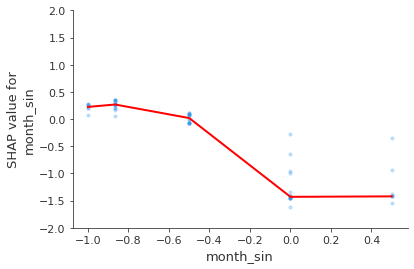

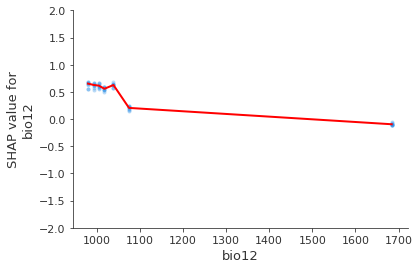

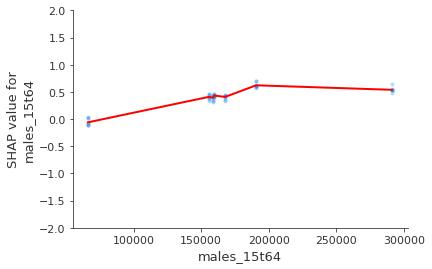

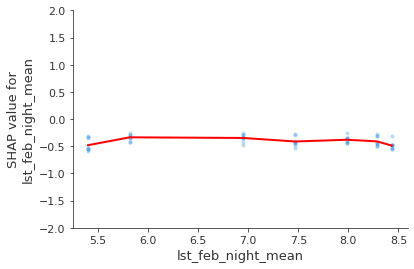

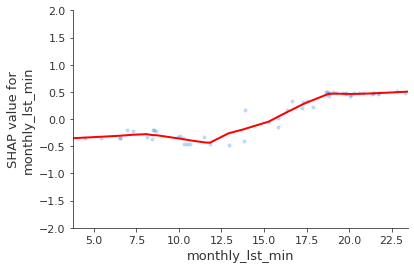

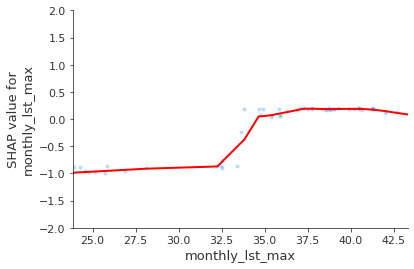

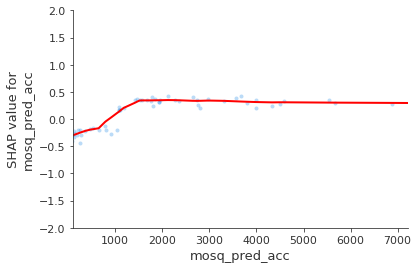

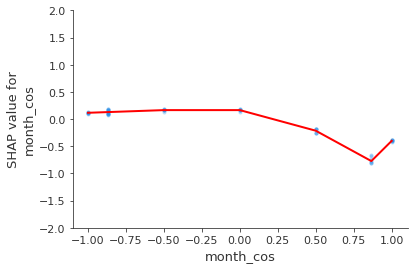

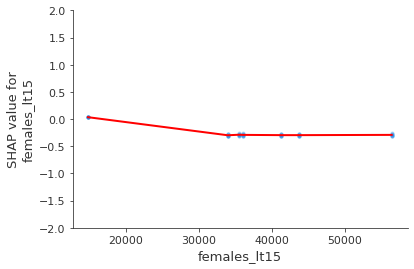

In [48]:
sorted_mean_abs_values_idx_attica_high = tree_shap_values_df[region_attica_high].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_attica_high[:10]:
    feature = ft
    shap_values = shap_values_df_attica_high
    data = X_train[region_attica_high]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)

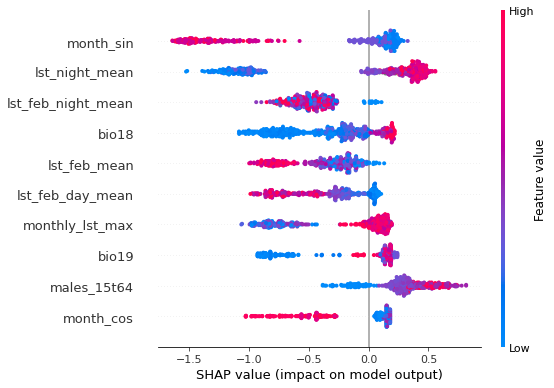

In [49]:
shap.summary_plot(shap_values_df_attica_low, feature_names = X_train.columns, features = X_train[region_attica_low], max_display=10)

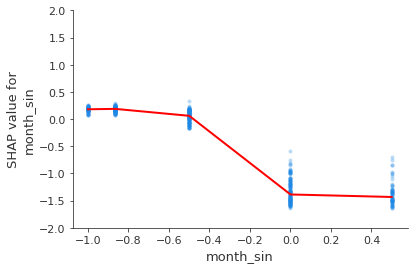

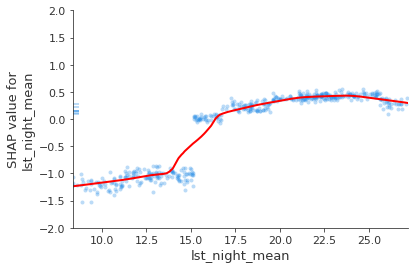

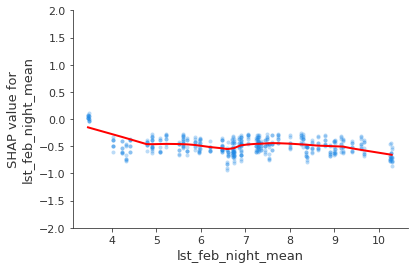

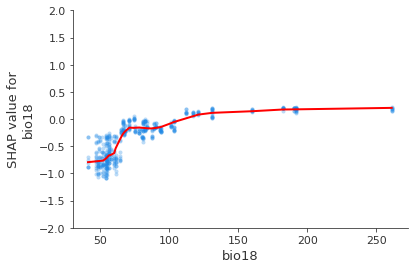

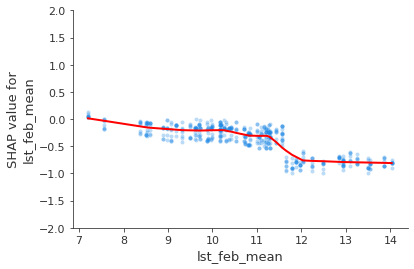

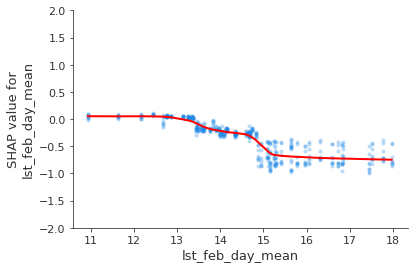

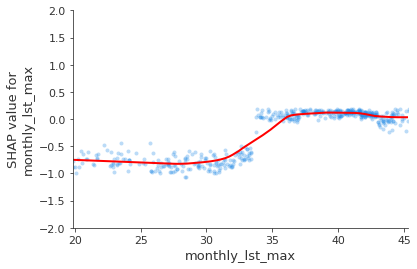

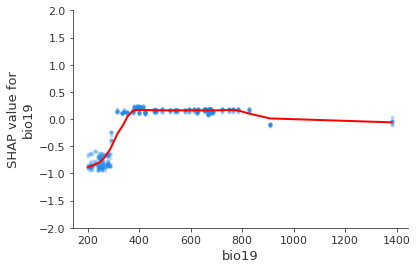

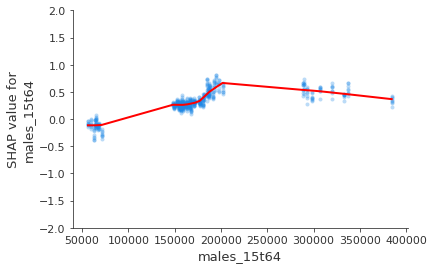

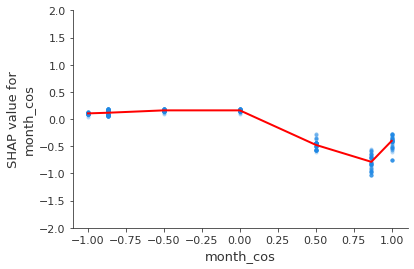

In [50]:
sorted_mean_abs_values_idx_attica_low = tree_shap_values_df[region_attica_low].iloc[:, 5:-1].abs().mean().sort_values(ascending=False).index
for ft in sorted_mean_abs_values_idx_attica_low[:10]:
    feature = ft
    shap_values = shap_values_df_attica_low
    data = X_train[region_attica_low]
    feature_names = data.columns

    idx = np.where(data.columns==feature)[0][0]
    x = data.iloc[:,idx]
    y_sv = shap_values[:,idx]
    lowess = sm.nonparametric.lowess(y_sv, x, it=2,frac=.3)
    _,ax = plt.subplots()
    ax.plot(*list(zip(*lowess)), color="red", lw = 2)
    ax.set_ylim(-2, 2)
    
    shap.dependence_plot(ind = feature, shap_values = shap_values, features = data, feature_names = feature_names, 
                         interaction_index=None, xmin="percentile(1)", xmax="percentile(99)", alpha=0.3, ax = ax)